### Point to Dataset

In [1]:
import os

#base_path = "/content/3DCNN-Tennis-Action-Recognition/tennis_dataset"
base_path = r"C:\Users\Mini-Berlink\Documents\UNT\26-Spring-CSCE5218\Assignment\Project\3DCNN-Tennis-Action-Recognition-main\tennis_dataset"
class_names = sorted(os.listdir(base_path))

print(class_names)

#Original Image Size = (480,852) #HEIGHT, WIDTH
HEIGHT, WIDTH = 180, 320 # Resize to this dimension


['b_slice', 'b_volley', 'backhand', 'f_volley', 'forehand', 'serve', 'smash']


### Load All action frames into Dataset

In [2]:
import os
import numpy as np
import cv2
import random

In [3]:

# User-defined parameters
F_STEP = 5 # Step size for frame collection
VIDEO_NUM_PER_ACTION = 50 # Number of videos to process per action category

actions = os.listdir(base_path)

# Initialize lists to store sequences of frames per video and their labels
all_video_sequences = []
all_video_labels = []

for action in actions:
    action_path = base_path + "/" + action

    # Assign a unique numerical label for the current action
    current_label = class_names.index(action)
    print(f"Label: {current_label}")

    videos = [f for f in os.listdir(action_path) if f.endswith('.mp4')]
    random.shuffle(videos)
    counter = 1

    for video in videos:
      # Stop processing videos for this action if we've reached the limit
      if counter > VIDEO_NUM_PER_ACTION:
          break

      video_path = action_path + "/" + video
      print(f"Processing: {video_path}")

      cap = cv2.VideoCapture(video_path)
      total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

      if total_frames == 0:
          cap.release()
          print(f"Skipping empty video: {video_path}")
          continue

      middle_frame = total_frames // 2
      frame_indices_set = set()

      # Add middle frame if valid
      if 0 <= middle_frame < total_frames:
          frame_indices_set.add(middle_frame)

      # Go backwards from middle frame
      current_frame_b = middle_frame - F_STEP
      while current_frame_b >= 0:
          frame_indices_set.add(current_frame_b)
          current_frame_b -= F_STEP

      # Go forwards from middle frame
      current_frame_f = middle_frame + F_STEP
      while current_frame_f < total_frames:
          frame_indices_set.add(current_frame_f)
          current_frame_f += F_STEP

      frame_numbers = sorted(list(frame_indices_set)) # These are 0-indexed frame numbers
      print(f"frame numbers: {frame_numbers}")

      current_video_frames = []
      for frame_number_0_indexed in frame_numbers:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number_0_indexed)
        ret, frame = cap.read()
        if ret:
          frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
          frame = cv2.resize(frame, (WIDTH, HEIGHT))
          frame = np.array(frame).astype(np.float32) # Ensure consistent dtype
          frame = frame / 255.0 # Normalize pixel values to [0, 1] here
          current_video_frames.append(frame)
        else:
          print(f"Frame {frame_number_0_indexed} not found in {video_path}")

      cap.release()

      if current_video_frames: # Only add if frames were successfully extracted
          all_video_sequences.append(np.array(current_video_frames)) # Store as a NumPy array
          all_video_labels.append(current_label)
      else:
          print(f"No frames extracted for {video_path}")

      counter += 1

# Convert lists of sequences and labels to numpy arrays
# X_full_clips will be an array of objects, where each object is a (sequence_length, H, W, C) numpy array
X_full_clips = np.array(all_video_sequences, dtype=object)
y_full_labels = np.array(all_video_labels)

print(f"Total videos processed: {len(X_full_clips)}")
print(f"Shape of X_full_clips (array of variable-length sequences): {X_full_clips.shape}")
print(f"Shape of y_full_labels: {y_full_labels.shape}")

# Individual clip label and shape:
for i in range(len(X_full_clips)):
    print(f"Clip {i}: label={y_full_labels[i]}, shape={X_full_clips[i].shape}")



Label: 2
Processing: C:\Users\Mini-Berlink\Documents\UNT\26-Spring-CSCE5218\Assignment\Project\3DCNN-Tennis-Action-Recognition-main\tennis_dataset/backhand/backhand19.mp4
frame numbers: [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61]
Processing: C:\Users\Mini-Berlink\Documents\UNT\26-Spring-CSCE5218\Assignment\Project\3DCNN-Tennis-Action-Recognition-main\tennis_dataset/backhand/backhand46.mp4
frame numbers: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
Processing: C:\Users\Mini-Berlink\Documents\UNT\26-Spring-CSCE5218\Assignment\Project\3DCNN-Tennis-Action-Recognition-main\tennis_dataset/backhand/backhand27.mp4
frame numbers: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
Processing: C:\Users\Mini-Berlink\Documents\UNT\26-Spring-CSCE5218\Assignment\Project\3DCNN-Tennis-Action-Recognition-main\tennis_dataset/backhand/backhand10.mp4
frame numbers: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
Processing: C:\Users\Mini-Berlink\Documents\UNT\26-Spring-CSCE5218\Assignment\Proje

In [ ]:
%%sql


In [4]:
# 1. Define a fixed length (12 is a safe choice since most are 12 or 13)
TARGET_LENGTH = 12

# 2. Add the alignment function
def standardize_sequences(sequences, target_len, height, width):
    processed = []
    for seq in sequences:
        if seq.shape[0] > target_len:
            # Truncate extra frames
            processed_seq = seq[:target_len]
        elif seq.shape[0] < target_len:
            # Pad missing frames with zeros
            padding = np.zeros((target_len - seq.shape[0], height, width, 3), dtype=seq.dtype)
            processed_seq = np.concatenate((seq, padding), axis=0)
        else:
            processed_seq = seq
        processed.append(processed_seq)
    return np.array(processed)

# 3. Process your collected frames
print(f"Standardizing all clips to {TARGET_LENGTH} frames...")
X_full_clips = standardize_sequences(all_video_sequences, TARGET_LENGTH, HEIGHT, WIDTH)

# 4. Final conversions
X_full_clips = X_full_clips.astype('float32') # Use float32 for Keras compatibility
y_full_labels = np.array(all_video_labels).astype('int32')

print(f"New X_full_clips shape: {X_full_clips.shape}")
# Result will be (350, 12, 180, 320, 3)

Standardizing all clips to 12 frames...
New X_full_clips shape: (350, 12, 180, 320, 3)


In [ ]:
#### Data saved in the project directory. Size of 600+ MB.
# Save the full preprocessed dataset
np.savez_compressed('tennis_full_dataset.npz',
                    X=X_full_clips,
                    y=y_full_labels)

print("Full dataset saved! You can now load frames from this file.")

In [ ]:
#### Note: It is very slow to reload the data and will crash the PC. Do NOT try to use this way to load
# Load the saved data
data = np.load('tennis_full_dataset.npz', allow_pickle=True)

# Extract the arrays
X_full_clips_L = data['X']
y_full_labels_L = data['y']

# IMPORTANT: Immediately convert to float32 to stop it from being an 'object'
X_full_clips_L = np.array(X_full_clips_L.tolist()).astype('float32')

print(f"Loaded X_full_clips shape: {X_full_clips_L.shape}")
print(f"Loaded y_full_labels shape: {y_full_labels_L.shape}")

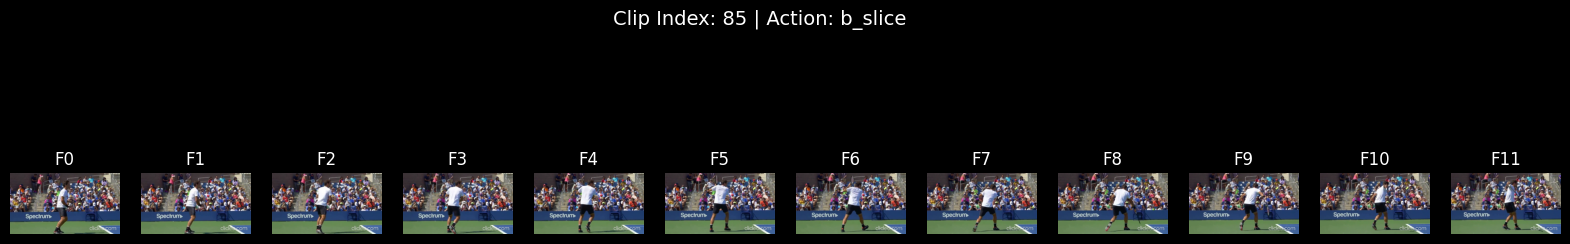

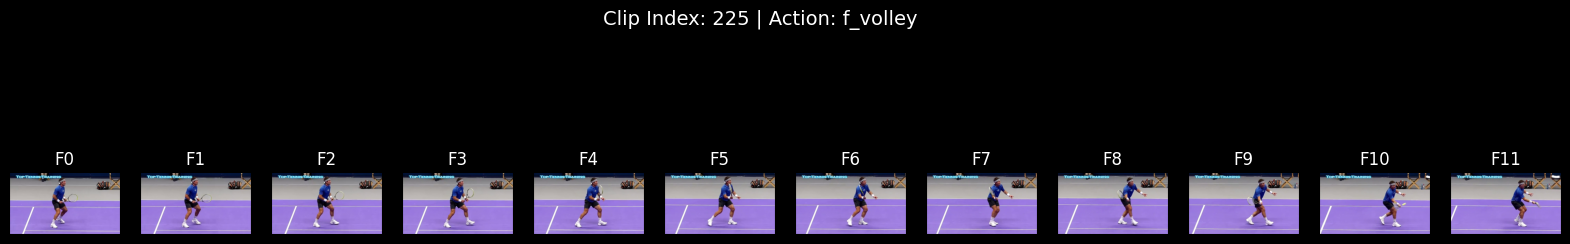

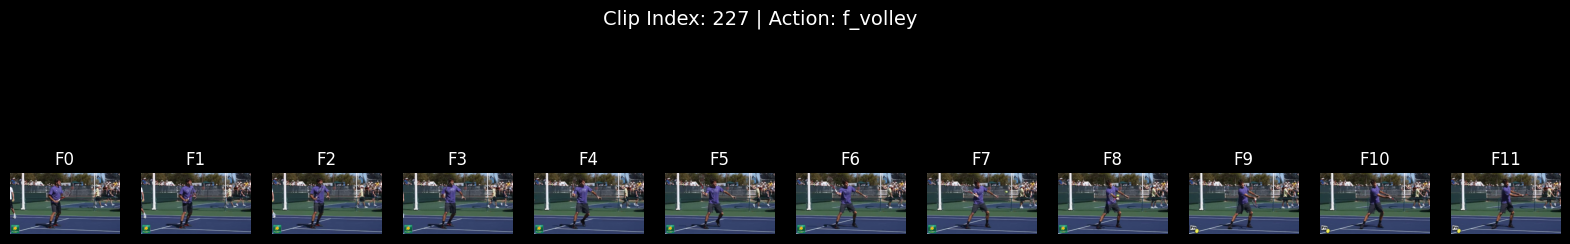

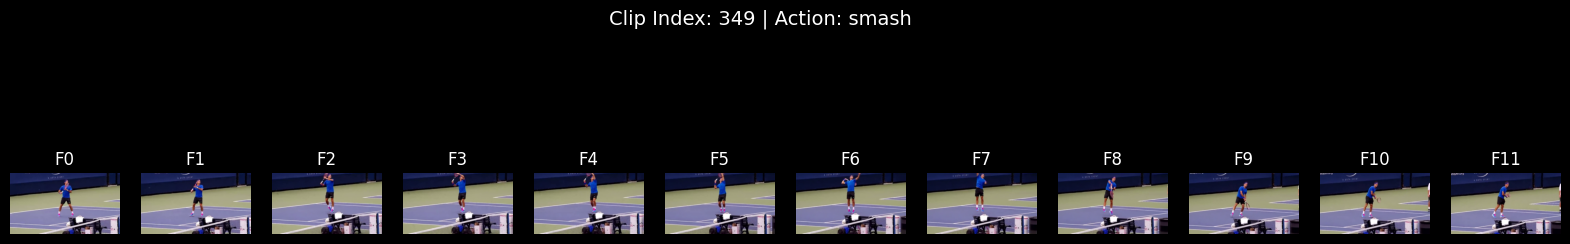

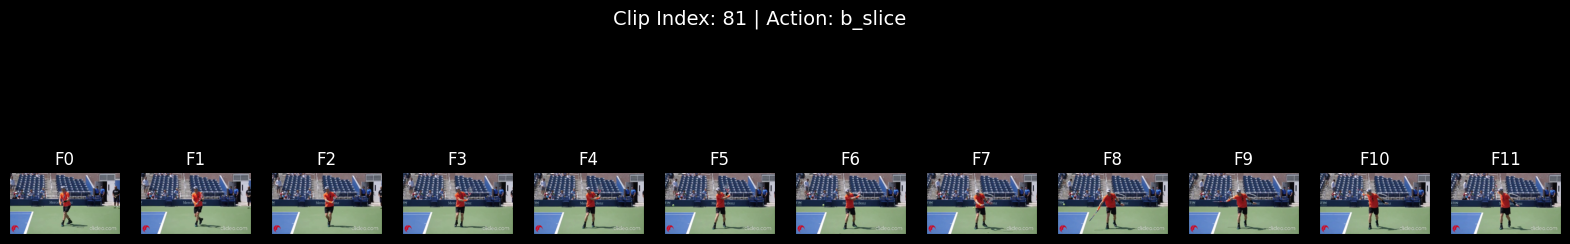

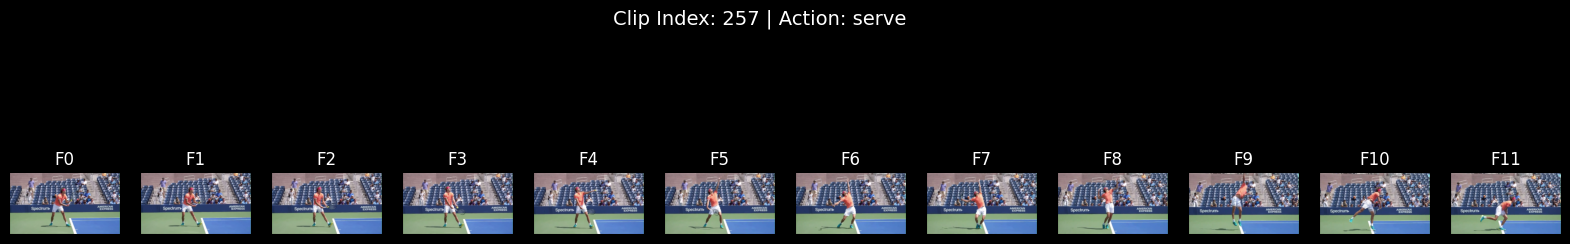

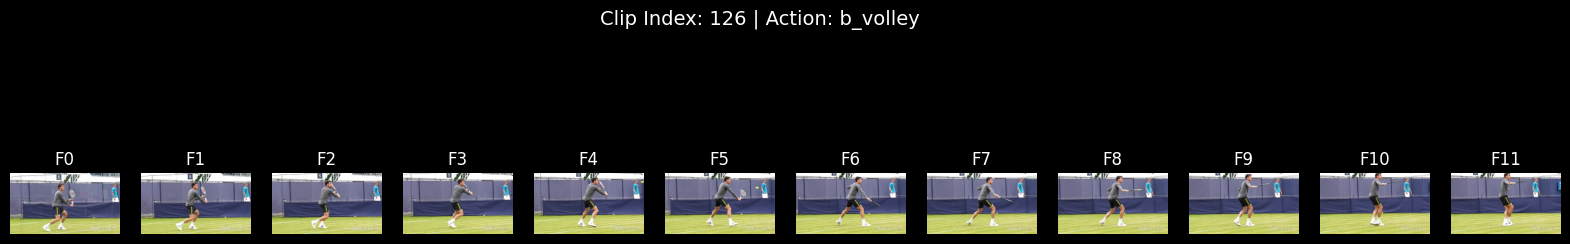

In [5]:
import matplotlib.pyplot as plt

def verify_filmstrip(X, y, class_names, num_samples=3):
    indices = np.random.choice(len(X), num_samples, replace=False)
    for idx in indices:
        clip = X[idx]
        label = class_names[y[idx]]

        fig, axes = plt.subplots(1, len(clip), figsize=(20, 4))
        fig.suptitle(f"Clip Index: {idx} | Action: {label}", fontsize=14)
        for i, frame in enumerate(clip):
            axes[i].imshow(frame)
            axes[i].axis('off')
            axes[i].set_title(f"F{i}")
        plt.show()

# Verify the standardized data
verify_filmstrip(X_full_clips, y_full_labels, class_names, 7)